In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
df = pd.read_csv('economic_index.csv')
df.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [3]:
# drop unneccessary columns

df.drop(columns=["Unnamed: 0", "year", "month"], axis=1, inplace=True)


In [4]:
df.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [5]:
# Check for missing values
df.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

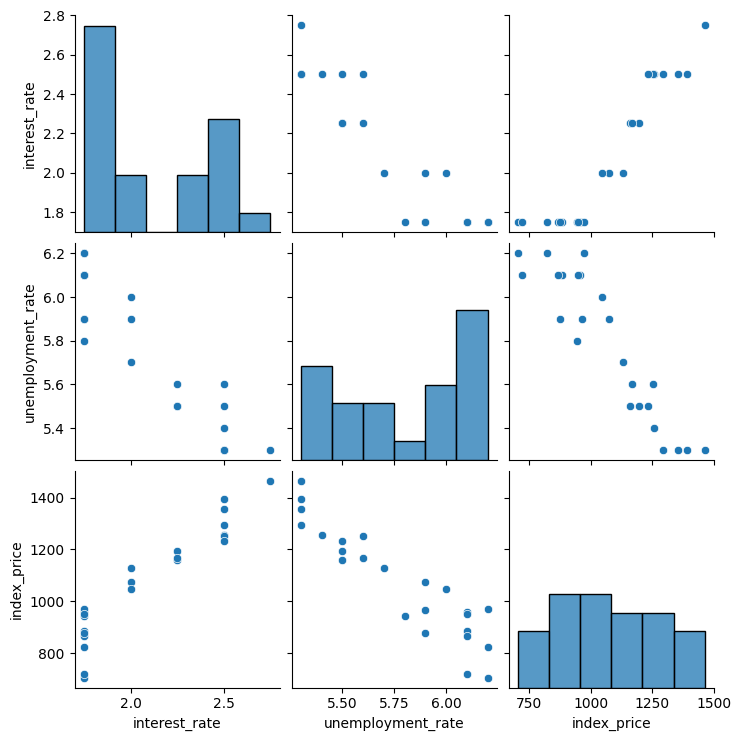

In [6]:
# Lets do some viualization
import seaborn as sns
sns.pairplot(df)

In [7]:
df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


Text(0.5, 1.0, 'Interest Rate vs Unemployment Rate')

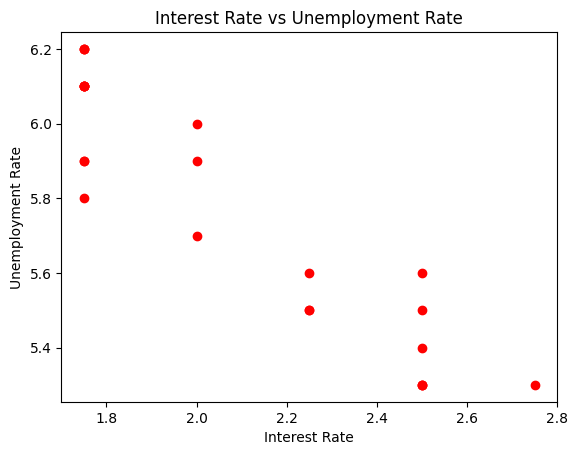

In [8]:
# Visualize the datapoints more closely
plt.scatter(df['interest_rate'], df['unemployment_rate'], color="r")

plt.xlabel("Interest Rate")
plt.ylabel("Unemployment Rate")
plt.title("Interest Rate vs Unemployment Rate")

In [9]:
# independent and dependent features
X = df.iloc[:, :-1]
y = df.iloc[:, -1]


In [10]:
X.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [11]:
y.head()

0    1464
1    1394
2    1357
3    1293
4    1256
Name: index_price, dtype: int64

In [12]:
# Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

<Axes: xlabel='interest_rate', ylabel='index_price'>

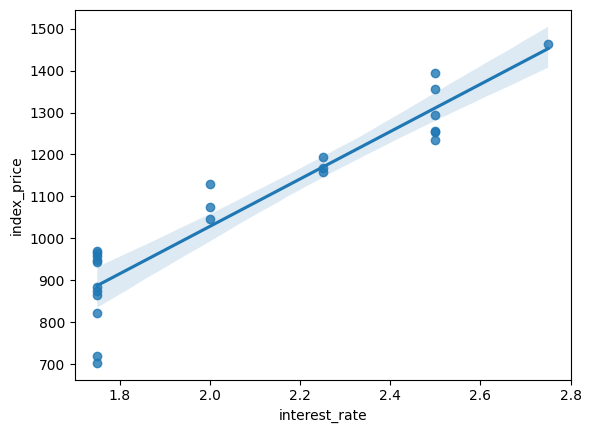

In [15]:
import seaborn as sns
sns.regplot(x=df['interest_rate'], y=df['index_price'])

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

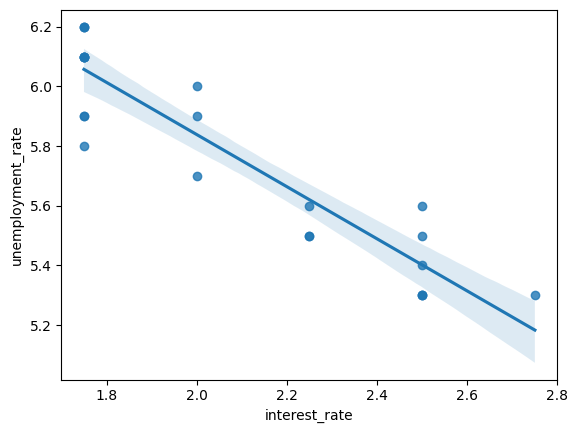

In [16]:
sns.regplot(x=df['interest_rate'], y=df['unemployment_rate'])

<Axes: xlabel='index_price', ylabel='unemployment_rate'>

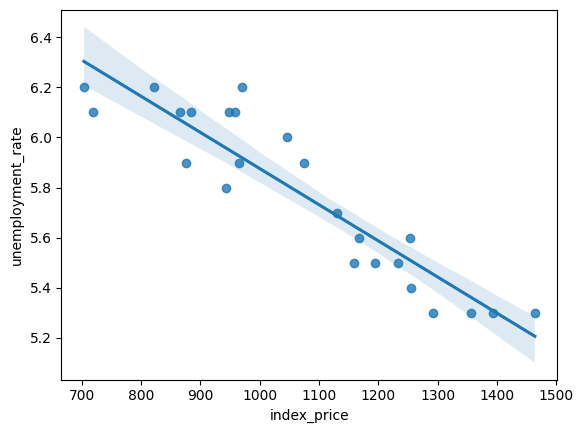

In [17]:
sns.regplot(x=df['index_price'], y=df['unemployment_rate'])

In [18]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
X_train

array([[-0.90115511,  0.37908503],
       [ 1.31077107, -1.48187786],
       [-0.90115511,  1.30956648],
       [ 1.31077107, -0.55139641],
       [ 1.31077107, -1.48187786],
       [-0.16384638,  0.68924552],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -1.48187786],
       [ 1.31077107, -1.17171738],
       [-0.90115511,  1.30956648],
       [-0.90115511,  0.999406  ],
       [-0.90115511,  0.37908503],
       [-0.90115511,  0.999406  ],
       [ 0.57346234, -0.8615569 ],
       [-0.16384638, -0.24123593],
       [-0.90115511,  0.06892455],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -0.8615569 ]])

In [20]:
X_test

array([[ 0.57346234, -0.8615569 ],
       [-0.90115511,  1.30956648],
       [ 2.0480798 , -1.48187786],
       [-0.90115511,  0.999406  ],
       [-0.16384638,  0.37908503],
       [ 0.57346234, -0.55139641]])

In [21]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()

regressor.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
# cross validation
from sklearn.model_selection import cross_val_score

validation_scores = cross_val_score(regressor, X_train, y_train, scoring='neg_mean_squared_error', cv=3)
validation_scores

array([-4921.61331265, -7686.87497294, -5135.9962549 ])

In [23]:
np.mean(validation_scores)

np.float64(-5914.828180162386)

In [24]:
# prediction
y_pred = regressor.predict(X_test)
y_pred

array([1204.22770398,  821.65051903, 1406.51300368,  857.70889608,
        994.90992298, 1168.16932693])

In [25]:
# Performance Metrics 
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)

Mean Absolute Error: 59.935781523235484
Mean Squared Error: 5793.762887712569
Root Mean Squared Error: 76.11677139574805


In [ ]:
from sklearn.metrics import r2_score
score = r2_score(y_test,y_pred)
print("R2 Score:",score)

# display adjusted R-squared
print("Adjusted R2 Score:", 1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1))

R2 Score: 0.8278978091457145
Adjusted R2 Score: 0.7131630152428576


Text(0.5, 1.0, 'Actual vs Predicted Index Price')

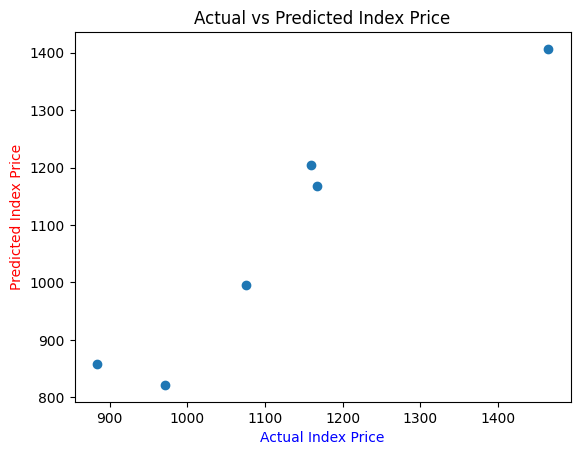

In [ ]:
# Assumptions

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Index Price", color="blue")
plt.ylabel("Predicted Index Price", color="red")
plt.title("Actual vs Predicted Index Price")

In [31]:
residuals = y_test - y_pred
print("Residuals:", residuals)

Residuals: 8     -45.227704
16    149.349481
0      57.486996
18     26.291104
11     80.090077
9      -1.169327
Name: index_price, dtype: float64


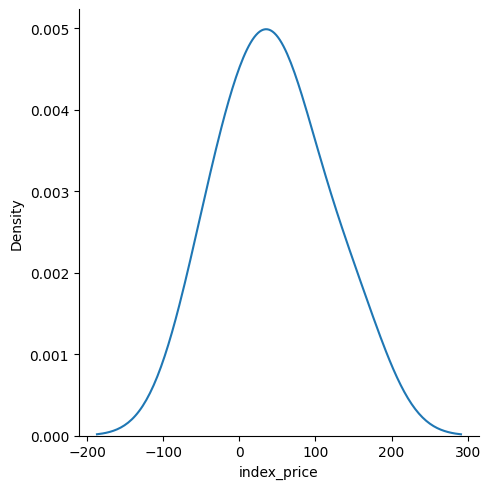

In [32]:
# Plot this residuals
sns.displot(residuals ,kind='kde')

Text(0.5, 1.0, 'Predicted Index Price vs Residuals')

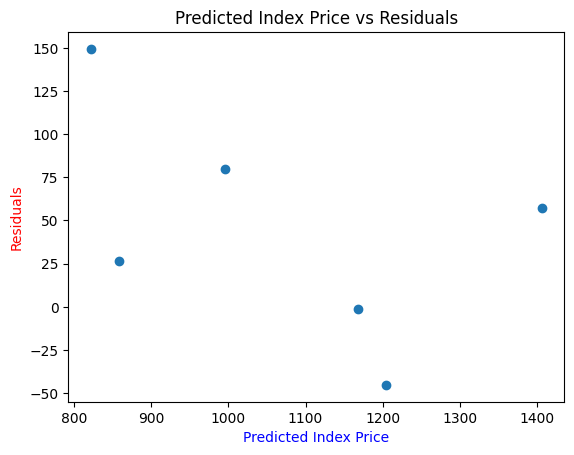

In [33]:
# scatter plot with respect to prediction and residuals
plt.scatter(y_pred, residuals)

plt.xlabel("Predicted Index Price", color="blue")
plt.ylabel("Residuals", color="red")
plt.title("Predicted Index Price vs Residuals")

In [34]:
# OLS Linear Regression
import statsmodels.api as sm

model = sm.OLS(y_train, X_train).fit()

predictions = model.predict(X_test)
print("Prediction:", predictions)

Prediction: [ 150.78325954 -231.79392541  353.06855924 -195.73554836  -58.53452146
  114.72488249]


In [35]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Mon, 20 Oct 2025   Prob (F-statistic):                       0.754
Time:                        07:44:13   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [36]:
print("Coefficients:", regressor.coef_)
print("Intercept:", regressor.intercept_)

Coefficients: [  88.27275507 -116.25716066]
Intercept: 1053.4444444444443
